# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import math 
import matplotlib.pyplot as plt

G = 6.67 * 10**(-11) 
g = 9.81 
M_earth = 5.9 * 10**24 
M_moon = 7.3 * 10**22 
M_apollo = 5500 
R_earth = 6378 * 10**3 
R_moon = 1737 * 10**3 
D_em = 3.8 * 10**8 
v_exh = 2.4 * 10**3 
dotm = 1.3*10**4 
m_wet = 2.8*10**6 
m_dry = 7.5*10**5 

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def Pot(xm, ym, x, y, M, eps=1e-9): 
    """ A function which calculates the potential strength

    Args:
        xm (float): x location of mass
        ym (float): y location of mass
        x (float): x location of potential
        y (float): y location of potential
        M (float): Mass of gravitating object
        
    Returns:
        float : Potential at (x,y) 
    """
    if not M > 0:
        raise ValueError(f"mass is not positive!")
    M = np.asarray(M) 
    dx = x - xm 
    dy = y - ym 
    r = np.hypot(dx,dy) 
    V = -(G*M)/r
    V = np.where(r < eps, np.nan, V)
    return V 
x = Pot(3000.0 , 3000.0, 3000.000000000001, 3000.00000000001, 1000000) 
print(x) 

nan


2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

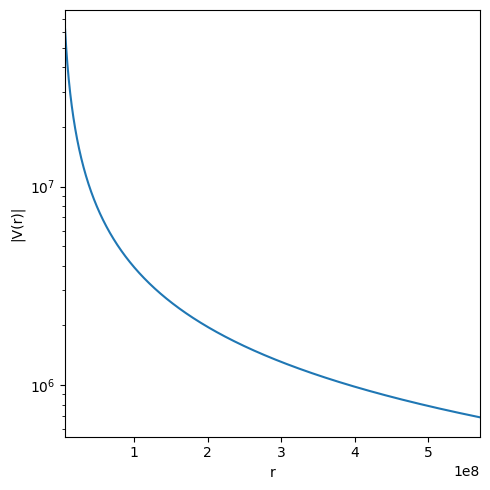

In [4]:
fig, ax= plt.subplots(figsize=(5,5))

space_grid = np.linspace(R_earth, 1.5*D_em, 10000) 

gpot = abs(Pot(0, 0, space_grid, 0, M_earth))

ax.plot(space_grid, gpot) 

ax.set_yscale("log")
ax.set_xlim(R_earth, 1.5*D_em)

ax.set_xlabel("r")
ax.set_ylabel("|V(r)|")
plt.tight_layout()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

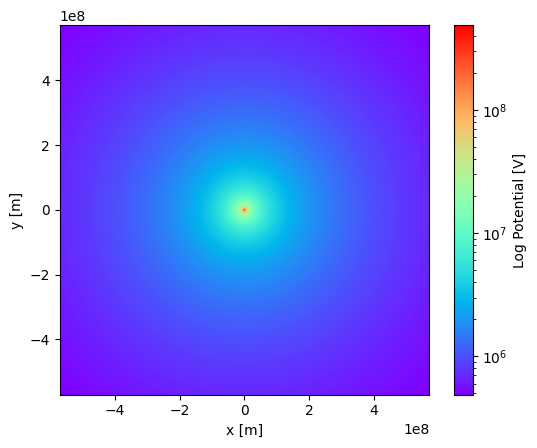

In [5]:
x = np.linspace(-1.5*D_em, 1.5*D_em, 1000) 
y = np.linspace(-1.5*D_em, 1.5*D_em, 1000) 

x_grid, y_grid = np.meshgrid(x,y) 

V = np.abs(Pot(0, 0, x_grid, y_grid, M_earth))

fig, ax=plt.subplots() 
mesh = ax.pcolormesh(x_grid,y_grid, V,norm = "log", cmap = 'rainbow')

cbar = fig.colorbar(mesh)
cbar.set_label("Log Potential [V]")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

ax.set_aspect("equal") 

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

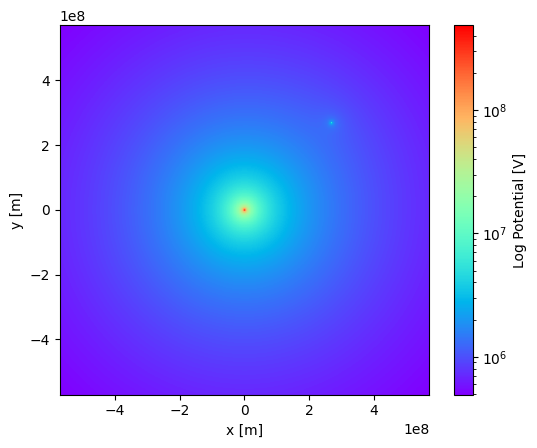

In [6]:
x = np.linspace(-1.5*D_em, 1.5*D_em, 1000) 
y = np.linspace(-1.5*D_em, 1.5*D_em, 1000) 

x_grid, y_grid = np.meshgrid(x,y) 

V_earth = np.abs(Pot(0, 0, x_grid, y_grid, M_earth))
V_moon = np.abs(Pot(D_em/np.sqrt(2), D_em/np.sqrt(2), x_grid, y_grid, M_moon))
V_tot = V_earth + V_moon

fig, ax=plt.subplots() 
mesh = ax.pcolormesh(x_grid,y_grid, V_tot ,norm = "log", cmap = 'rainbow')

cbar = fig.colorbar(mesh)
cbar.set_label("Log Potential [V]")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal") 

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

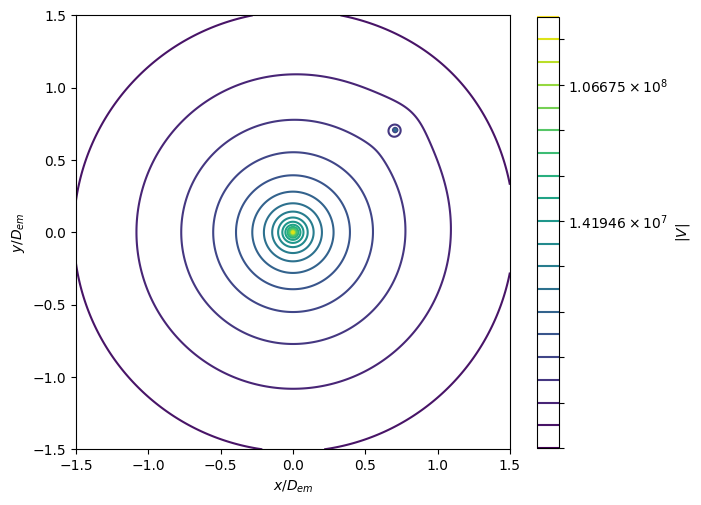

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

x = np.linspace(-1.5 * D_em, 1.5 * D_em, 600)
y = np.linspace(-1.5 * D_em, 1.5 * D_em, 600)

x_grid, y_grid = np.meshgrid(x, y)

V_earth = np.abs(Pot(0, 0, x_grid, y_grid, M_earth))
V_moon = np.abs(Pot(D_em/np.sqrt(2), D_em/np.sqrt(2), x_grid, y_grid, M_moon))
V_tot = V_earth + V_moon

# choose log-spaced contour levels
vmin = np.nanmin(V_tot[V_tot > 0])
vmax = np.nanmax(V_tot)
levels = np.geomspace(vmin, vmax, 20)

fig, ax = plt.subplots(figsize=(7,7))

contour = ax.contour(
    x_grid / D_em,
    y_grid / D_em,
    V_tot,
    levels=levels,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cmap="viridis"
)


cbar = fig.colorbar(contour, ax=ax, shrink=0.8)
cbar.set_label(r"$|V|$")

ax.set_aspect("equal")
ax.set_xlabel(r"$x/D_{em} $")
ax.set_ylabel(r"$y/D_{em} $")

plt.show()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def G_force(x1,y1,M1,x2,y2,M2, eps = 1.6 * 10**(-6)):
    dx = x2 - x1 
    dy = y2 - y1 

    r = np.hypot(dx,dy) 
    r_squared = r**2 

    r_hat_x = dx/r
    r_hat_y = dy/r 

    Fx = -G * M1 * M2 / r_squared * r_hat_x 
    Fy = -G * M1 * M2 / r_squared * r_hat_y 

    Fx = np.where(r < eps, np.nan, Fx) 
    Fy = np.where(r < eps, np.nan, Fy) 
    
    return Fx, Fy


2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

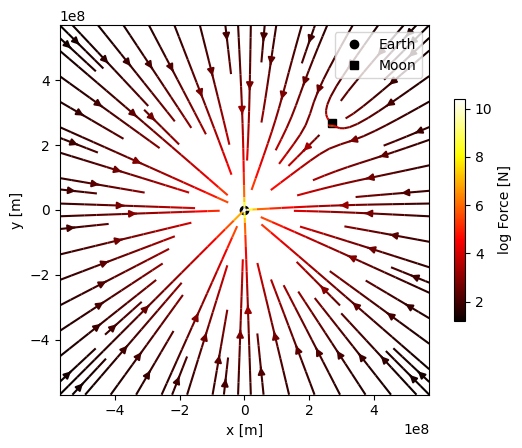

In [9]:
nx = 100 
ny = 100 

x = np.linspace(-1.5*D_em, 1.5*D_em, nx) 
y = np.linspace(-1.5*D_em, 1.5*D_em, ny) 

x_grid, y_grid = np.meshgrid(x,y) 
 
Fx_ea, Fy_ea = G_force(0,0,M_earth, x_grid, y_grid, M_apollo)
Fx_ma, Fy_ma = G_force(D_em/np.sqrt(2), D_em/np.sqrt(2),M_moon, x_grid, y_grid, M_apollo)

Fx = Fx_ea + Fx_ma 
Fy = Fy_ma + Fy_ea 

fig, ax=plt.subplots() 


ax.plot([0], [0], "ko", label="Earth") 
ax.plot([D_em/np.sqrt(2)], [D_em/np.sqrt(2)], "ks", label="Moon") 
colors = np.hypot(Fx,Fy) 
colors = np.log(np.hypot(Fx,Fy)) 

import matplotlib.cm as cm 
stream = ax.streamplot(x, y, Fx, Fy, color = colors, cmap=cm.hot) 
ax.set_aspect("equal") 

ax.set_xlabel("x [m]") 
ax.set_ylabel("y [m]")
cbar = fig.colorbar(stream.lines, shrink = 0.6)
cbar.set_label("log Force [N]")
ax.legend(loc = "upper right")

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

$\frac{GM_\text{moon}M_\text{apollo}}{r_\text{ma}^2} = \frac{GM_\text{earth}M_\text{apollo}}{r_\text{b}^2} $

Which then implies that 

$\frac{M_\text{moon}}{(r_m - r_b)^2} = \frac{M_\text{earth}}{r_\text{b}^2} $

We can take the square root of both sides and then do some algebra to arrive at the following expression 

$r_b = \frac{r_m \sqrt{M_e}}{\sqrt{M_m} + \sqrt{M_e}}$

We can plug in our defined values, and we arrive at 

$r_b = 3.4*10^8 $ m

And since we are just on a line between the moon and the earth, and the moon is at equal y and x coordinate, we have

$2x_b^2 = r_b^2 $ 

which implies that $x_b = y_b = \frac{r_b}{\sqrt{2}}$

Thus $(x_b,y_b) = (241803894,241803894)$

And your updated plot, including the balance point, goes in the cell below.

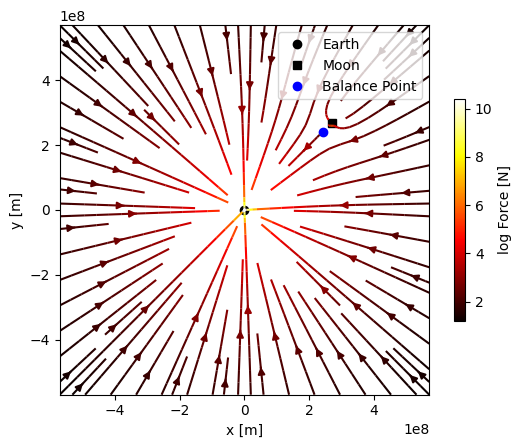

In [10]:
nx = 100 
ny = 100 

x = np.linspace(-1.5*D_em, 1.5*D_em, nx) 
y = np.linspace(-1.5*D_em, 1.5*D_em, ny) 

x_grid, y_grid = np.meshgrid(x,y) 
 
Fx_ea, Fy_ea = G_force(0,0,M_earth, x_grid, y_grid, M_apollo)
Fx_ma, Fy_ma = G_force(D_em/np.sqrt(2), D_em/np.sqrt(2),M_moon, x_grid, y_grid, M_apollo)

Fx = Fx_ea + Fx_ma 
Fy = Fy_ma + Fy_ea 

fig, ax=plt.subplots() 


ax.plot([0], [0], "ko", label="Earth") 
ax.plot([D_em/np.sqrt(2)], [D_em/np.sqrt(2)], "ks", label="Moon") 
ax.plot([241803894], [241803894], "bo", label="Balance Point") 

colors = np.hypot(Fx,Fy) 
colors = np.log(np.hypot(Fx,Fy)) 

import matplotlib.cm as cm 
stream = ax.streamplot(x, y, Fx, Fy, color = colors, cmap=cm.hot) 
ax.set_aspect("equal") 

ax.set_xlabel("x [m]") 
ax.set_ylabel("y [m]")
cbar = fig.colorbar(stream.lines, shrink = 0.6)
cbar.set_label("log Force [N]")
ax.legend(loc = "upper right")

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

It is far closer to the moon than the earth. In fact it is about 90% closer to the moon than the earth. This makes sense as the moon's gravitational field is far weaker than that of the earth. In order for the forces to cancel out, you need to be closer to the moon in order for the gravitational field to be on par with that of the earth. 

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
def T_burn(m_0, m_f, dotm):
    T = (m_0 - m_f)/dotm 
    return T

burn_time = T_burn(m_wet, m_dry, dotm)
print(burn_time)

157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def delta_v(t,m_0,m_f,dotm,v_ex,g):
    t = np.asarray(t)
    m_t = m_0 - dotm * t 
    t_b = T_burn(m_0, m_f, dotm) 

    if m_0 <= 0 or m_f <= 0:
        raise ValueError("masses must be positive")
    if m_f >= m_0:
        raise ValueError("m_f must be less than m_0")
    if dotm <= 0:
        raise ValueError("dotm must be positive")
    
    if m_t <= m_f:
        dv = v_ex * np.log(m_0/m_f) - g*t_b 
        return dv 
        
    dv = v_ex * np.log(m_0/m_t) - g*t 
    return dv 

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
import scipy

burn_time = T_burn(m_wet, m_dry, dotm)

h, err = scipy.integrate.quad(delta_v, 0, burn_time,
                              args=(m_wet, m_dry, dotm, v_exh, g))

print(h)
print(err)

74093.98013366401
5.848811185394151e-08


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

For our burn time, we found $t_b = 157$ seconds, and for our altitude we found $h = 74$ km. Our burn time is an underestimate. This could be due to imperfections in the engine or the rocket and its ability to dispense fuel at the given rate. That we overestimated the height is in part due to the burn time. Since the burn time took longer, that implies gravity had more time to act. Also the burned energy most likely does not all convert into useful momentum that launches the rocket upwards. Some may be in the form of thermal energy or vibrations in lateral directions. 